In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [69]:
df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3228\3062298247.py:1: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
scores_connus = ['a', 'b', 'c', 'd', 'e']
df_connu = df[df['nutriscore_grade'].isin(scores_connus)].copy()

# DataFrame avec le reste (unknown, not-applicable, ou NaN éventuels)
df_inconnu = df[~df['nutriscore_grade'].isin(scores_connus)].copy()

# Vérification rapide
print("Connu :", df_connu.shape)
print("Inconnu :", df_inconnu.shape)
print(df_connu['nutriscore_grade'].value_counts())
print(df_inconnu['nutriscore_grade'].value_counts(dropna=False))

Connu : (965, 211)
Inconnu : (9035, 211)
nutriscore_grade
e    306
d    209
c    190
a    171
b     89
Name: count, dtype: int64
nutriscore_grade
unknown           8455
NaN                313
not-applicable     267
Name: count, dtype: int64


In [71]:
df.columns.tolist()

['code',
 'url',
 'creator',
 'created_t',
 'created_datetime',
 'last_modified_t',
 'last_modified_datetime',
 'last_modified_by',
 'last_updated_t',
 'last_updated_datetime',
 'product_name',
 'abbreviated_product_name',
 'generic_name',
 'quantity',
 'packaging',
 'packaging_tags',
 'packaging_en',
 'packaging_text',
 'brands',
 'brands_tags',
 'brands_en',
 'categories',
 'categories_tags',
 'categories_en',
 'origins',
 'origins_tags',
 'origins_en',
 'manufacturing_places',
 'manufacturing_places_tags',
 'labels',
 'labels_tags',
 'labels_en',
 'emb_codes',
 'emb_codes_tags',
 'first_packaging_code_geo',
 'cities',
 'cities_tags',
 'purchase_places',
 'stores',
 'countries',
 'countries_tags',
 'countries_en',
 'ingredients_text',
 'ingredients_tags',
 'ingredients_analysis_tags',
 'allergens',
 'allergens_en',
 'traces',
 'traces_tags',
 'traces_en',
 'serving_size',
 'serving_quantity',
 'no_nutrition_data',
 'additives_n',
 'additives',
 'additives_tags',
 'additives_en',
 'nu

In [72]:
features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g','proteins_100g', 'fruits-vegetables-legumes_100g', 'countries','energy-kcal_100g', 'cholesterol_100g','carbohydrates_100g']

#nnitrate et sulphate sont vides, glucose et cholesterol, lactose sont pas ouf


In [73]:
#Nettoyage minimal des données
percent_missing = df_connu[features].isnull().sum() * 100 / len(df_connu)
percent_missing.sort_values(ascending=False,inplace=True)

In [74]:
print(percent_missing)

cholesterol_100g                  87.150259
fruits-vegetables-legumes_100g    73.160622
carbohydrates_100g                40.310881
saturated-fat_100g                40.310881
sugars_100g                       40.310881
energy_100g                       40.207254
proteins_100g                     40.207254
salt_100g                         40.207254
energy-kcal_100g                  40.207254
countries                          0.829016
dtype: float64


In [75]:
## On retire les features avec + de 80% de valeurs manquantes
threshold = 90
columns_to_drop = percent_missing[percent_missing.values > threshold].index
print(columns_to_drop)
#features_restantes = [f for f in features if f not in columns_to_drop]
features_restantes = [f for f in features if f != 'fruits-vegetables-legumes_100g'] # plus problematique"


Index([], dtype='str')


In [76]:
##il y a des lignes avec des NaN dans chaque features, il faut les supprimer !
df_restr = df_connu[features_restantes + ['nutriscore_grade']].copy() 
n_features = len(features_restantes)
df_restr= df_restr[df_restr[features_restantes].isna().sum(axis=1) != n_features]

In [77]:
len(df_restr)

957

In [78]:
df_restr.shape

(957, 10)

In [79]:
# 4. SPLIT MAINTENANT, avant imputation et avant traitement des outliers
X =df_restr[features_restantes]
y = df_restr['nutriscore_grade']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

cols_numeriques = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
                    'proteins_100g',
                    'energy-kcal_100g','carbohydrates_100g']
cols_categorielles = ['countries']

imputer = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), cols_numeriques),
        ('cat', SimpleImputer(strategy='most_frequent'), cols_categorielles),
    ]
)

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=cols_numeriques + cols_categorielles,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=cols_numeriques + cols_categorielles,
    index=X_test.index
)

# Correction du dtype : ColumnTransformer renvoie tout en object à cause du mélange num/texte
X_train_imputed[cols_numeriques] = X_train_imputed[cols_numeriques].astype(float) 
X_test_imputed[cols_numeriques] = X_test_imputed[cols_numeriques].astype(float)

In [81]:
def remove_outliers_iqr(df_features, cols, bounds=None):
    """Si bounds=None, les calcule sur df_features (à utiliser seulement sur train)."""
    masque = pd.Series(False, index=df_features.index)
    if bounds is None:
        bounds = {}
        for col in cols:
            Q1, Q3 = df_features[col].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            bounds[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    for col in cols:
        low, high = bounds[col]
        masque |= (df_features[col] < low) | (df_features[col] > high)
    return masque, bounds
cols_outliers = [c for c in cols_numeriques if c != 'energy_100g']

masque_train, bounds = remove_outliers_iqr(X_train_imputed, cols_outliers)
X_train_clean = X_train_imputed[~masque_train]
y_train_clean = y_train.loc[X_train_clean.index]

masque_test, _ = remove_outliers_iqr(X_test_imputed, cols_outliers, bounds=bounds)
X_test_clean = X_test_imputed[~masque_test]
y_test_clean = y_test.loc[X_test_clean.index]

In [82]:
print("Outliers dans train :", masque_train.sum())
print("Outliers dans test :", masque_test.sum())

Outliers dans train : 338
Outliers dans test : 91


In [83]:
total_attendu = len(X_train_imputed) - masque_train.sum() + len(X_test_imputed) - masque_test.sum()
print("Total attendu :", total_attendu)

Total attendu : 528


In [84]:
print("Total obtenu :", len(y_train_clean) + len(y_test_clean)) #verification que le nombre d'échantillons après nettoyage correspond au nombre attendu

Total obtenu : 528


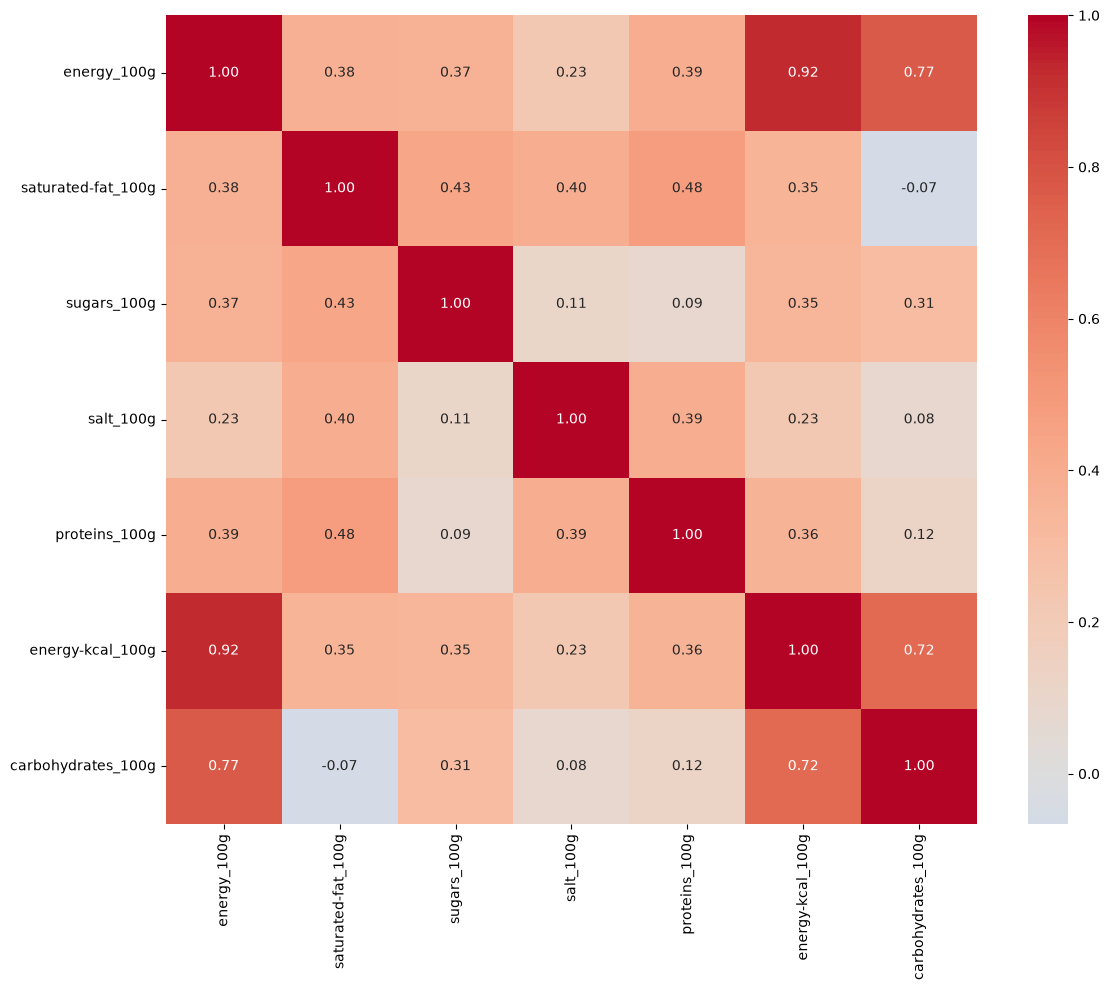

             variable        VIF
0         energy_100g  10.378151
1  saturated-fat_100g   2.845224
2         sugars_100g   1.554607
3           salt_100g   1.301727
4       proteins_100g   1.556806
5    energy-kcal_100g   6.745356
6  carbohydrates_100g   4.447992

Variables gardées (VIF < 5.0) : ['saturated-fat_100g', 'sugars_100g', 'salt_100g', 'proteins_100g', 'carbohydrates_100g']


c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Optimization terminated successfully.
         Current function value: 1.282577
         Iterations: 73
         Function evaluations: 74
         Gradient evaluations: 74


c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of p

                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -547.66
Model:                   OrderedModel   AIC:                             1263.
Method:            Maximum Likelihood   BIC:                             1604.
Date:                Wed, 26 Aug 2026                                         
Time:                        15:55:20                                         
No. Observations:                 427                                         
Df Residuals:                     343                                         
Df Model:                          80                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
energy_100g                                          

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Lignes utilisées : 427
Accuracy (train) : 0.588

Coefficients par classe (Lasso logistique) :

  Classe 'a' :
    energy_100g: 0.0000
    saturated-fat_100g: 0.0000
    sugars_100g: 0.0000
    salt_100g: -0.2202
    proteins_100g: 0.3291
    energy-kcal_100g: 0.0083
    carbohydrates_100g: 0.0000
    countries_Allemagne: 0.0000
    countries_Argentina: 0.0000
    countries_BE: 0.0000
    countries_Belgien, Germany: 0.1635
    countries_Belgique,France,Monde: 0.0713
    countries_Belgium: 0.0975
    countries_Brasil: 0.0000
    countries_Bulgaria: 0.0000
    countries_Canada: 0.1360
    countries_Canada,United States: 0.2083
    countries_DE: 0.1635
    countries_Deutschland: 0.0000
    countries_España: 0.0000
    countries_France: 0.0000
    countries_France,Royaume-Uni: 0.0000
    countries_Francia,España: 0.0000
    countries_Frankreich, Germany: 0.0000
    countries_Germany: 0.0000
    countries_Germany,Spain: 0.1635
    countries_Germany,en:germany: 0.1635
    countries_India: 0.6

In [85]:
from version2 import (
    plot_correlation_matrix,
    compute_vif,
    encode_categorical,
    train_ordinal_logit,
    evaluate_ordinal_model,
    run_lasso_logit,
)

df_train_full = X_train_clean.copy()
df_train_full['nutriscore_grade'] = y_train_clean

# Diagnostics sur variables numériques uniquement
corr = plot_correlation_matrix(df_train_full, cols_categorielles=cols_categorielles)
vif_data, vif_ok = compute_vif(df_train_full, cols_categorielles=cols_categorielles)

# Encodage juste avant l'entraînement
X_train_final, X_test_final, encoder = encode_categorical(
    X_train_clean, X_test_clean, cols_categorielles, cols_numeriques
)

# Entraînement sur les données encodées
result, scaler = train_ordinal_logit(X_train_final, y_train_clean)
pred, probas = evaluate_ordinal_model(result, scaler, X_test_final, y_test_clean)

model, lasso_scaler = run_lasso_logit(X_train_final, y_train_clean)

In [86]:
df_num_check = df_train_full.drop(columns=['nutriscore_grade'] + cols_categorielles, errors='ignore')
print(df_num_check.columns.tolist())
print(df_num_check.shape)

['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'proteins_100g', 'energy-kcal_100g', 'carbohydrates_100g']
(427, 7)


# Ce qu'on obtient :
* Une heatmap de corrélation  --> voir si des variables covarient entre elles, dans ce cas pas besoin de prendre toutes les var mais selectionner les plus pertinentes
* Un tableau de VIF + liste des variables <5 :  Plus le VIF d'une variable est élevé (>5), plus elle est "expliquée" par les autres variables du modèle — donc potentiellement redondante,  signale un problème de multicolinéarité.
*  modèle ordinal : les coef du mod indique la direction de l'effet d'une variable sur le nutriscore. par exemple signifierait que plus il y a de sucre, plus la probabilité d'être dans une classe "pire" (vers 'e') augmente
4 seuils pour 5 catégories : positionne les frontières entre catégories sur l'échelle latente. Dans un modèle ordinal (contrairement à une régression linéaire classique), il n'y a pas une seule constante/intercept, mais plusieurs seuils de coupure (appelés thresholds ou cutpoints), un entre chaque paire de catégories adjacentes. C'est le principe même du modèle : il suppose qu'il existe une variable latente continue (un "score de risque" sous-jacent) et que tes 5 catégories observées (a, b, c, d, e) sont obtenues en découpant cette échelle continue à des seuils précis.                                                                                
a/b = -3.6532 : le seuil séparant la catégorie 'a' de 'b' sur l'échelle latente
b/c = 0.3839 : le seuil séparant 'b' de 'c'
c/d = 1.1577 : le seuil séparant 'c' de 'd'
d/e = 1.2086 : le seuil séparant 'd' de 'e'
Le fait que a/b, b/c, c/d, d/e soient croissants (-3.65-> 0.38 → 1.16 → 1.21) est cohérent avec la logique ordinale : les seuils doivent être ordonnés.
* Une accuracy = ici accuracy = 68% = pourcentage de prédictions correctes sur le jeu de test
* matrice de confusion pour évaluer ce modèle sur le test :  un tableau 5×5 (car 5 classes a-e) où chaque ligne est la vraie classe et chaque colonne la classe prédite ; la diagonale montre les bonnes prédictions cad cb de produits ont bien été classés, le reste les erreurs (et dans quel sens le modèle se trompe — ex. confond souvent 'b' avec 'c' cad cb de b ont été classés en c).
* Des coefficients par classe issus du Lasso logistique, pour aider à la sélection de variables : pour chacune des 5 classes (a, b, c, d, e), la liste des variables avec leur coefficient associé à cette classe précise (dans un modèle multinomial, chaque classe a son propre jeu de coefficients par rapport aux autres).Si 0 = doit etre enlevé du modele

Un coefficient positif pour saturated-fat_100g (2.4167, très significatif avec p=0.000) signifie que plus il y a de graisses saturées, plus le score latent augmente — donc plus la probabilité de basculer vers une catégorie "pire" (vers 'e') est élevée. C'est cohérent avec l'intuition nutritionnelle.

À l'inverse, proteins_100g a un coefficient négatif (-0.9199, significatif) : plus il y a de protéines, plus le score latent diminue, donc plus la probabilité de rester dans une bonne catégorie (vers 'a') est élevée. Ça aussi c'est cohérent.

En revanche fat_100g n'a pas l'air d'expliquer le nutriscore

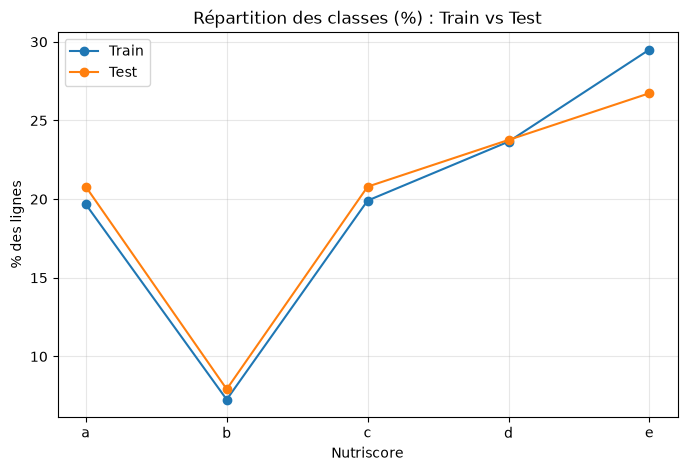

In [87]:

ordre = ['a', 'b', 'c', 'd', 'e']
train_pct = y_train_clean.value_counts(normalize=True).reindex(ordre) * 100
test_pct = y_test_clean.value_counts(normalize=True).reindex(ordre) * 100

plt.figure(figsize=(8, 5))
plt.plot(ordre, train_pct.values, marker='o', label='Train')
plt.plot(ordre, test_pct.values, marker='o', label='Test')
plt.xlabel('Nutriscore')
plt.ylabel('% des lignes')
plt.title('Répartition des classes (%) : Train vs Test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [88]:
# Accuracy sur train

ORDRE_NUTRISCORE = ["a", "b", "c", "d", "e"]
from sklearn.metrics import accuracy_score
X_train_scaled = pd.DataFrame(scaler.transform(X_train_final), columns=X_train_final.columns, index=X_train_final.index)
probas_train = result.predict(X_train_scaled)
probas_train.columns = ORDRE_NUTRISCORE
pred_train = probas_train.idxmax(axis=1)
acc_train = accuracy_score(y_train_clean, pred_train)

# Accuracy sur test (déjà calculée dans evaluate_ordinal_model, on la refait ici pour l'avoir en variable)
acc_test = accuracy_score(y_test_clean, pred)  # `pred` vient de evaluate_ordinal_model

print(f"Accuracy train : {acc_train:.3f}")
print(f"Accuracy test : {acc_test:.3f}")

Accuracy train : 0.506
Accuracy test : 0.416


In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def plot_learning_curve_ordinal(X_train, y_train, X_test, y_test, ordre=ORDRE_NUTRISCORE, n_points=8, random_state=42):
    """
    Trace la learning curve d'un modèle ordinal en faisant varier
    la taille du jeu d'entraînement.
    """
    tailles = np.linspace(0.1, 1.0, n_points)
    train_scores = []
    test_scores = []
    n_samples_list = []

    rng = np.random.RandomState(random_state)

    for frac in tailles:
        n = int(frac * len(X_train))
        idx = rng.choice(X_train.index, size=n, replace=False)
        X_sub = X_train.loc[idx]
        y_sub = y_train.loc[idx]

        # entraînement sur le sous-échantillon
        result, scaler = train_ordinal_logit(X_sub, y_sub, ordre=ordre)

        # accuracy sur le sous-échantillon d'entraînement lui-même
        X_sub_scaled = pd.DataFrame(scaler.transform(X_sub), columns=X_sub.columns, index=X_sub.index)
        probas_train = result.predict(X_sub_scaled)
        probas_train.columns = ordre
        pred_train = probas_train.idxmax(axis=1)
        train_scores.append(accuracy_score(y_sub, pred_train))

        # accuracy sur le jeu de test (fixe, toujours le même)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
        probas_test = result.predict(X_test_scaled)
        probas_test.columns = ordre
        pred_test = probas_test.idxmax(axis=1)
        test_scores.append(accuracy_score(y_test, pred_test))

        n_samples_list.append(n)

    plt.figure(figsize=(8, 5))
    plt.plot(n_samples_list, train_scores, marker='o', label='Train accuracy')
    plt.plot(n_samples_list, test_scores, marker='o', label='Test accuracy')
    plt.xlabel("Nombre d'échantillons d'entraînement")
    plt.ylabel("Accuracy")
    plt.title("Learning curve — modèle ordinal")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return n_samples_list, train_scores, test_scores



Optimization terminated successfully.
         Current function value: 1.373798
         Iterations: 46
         Function evaluations: 47
         Gradient evaluations: 47
                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -57.700
Model:                   OrderedModel   AIC:                             137.4
Method:            Maximum Likelihood   BIC:                             156.5
Date:                Wed, 26 Aug 2026                                         
Time:                        15:56:20                                         
No. Observations:                  42                                         
Df Residuals:                      31                                         
Df Model:                           7                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

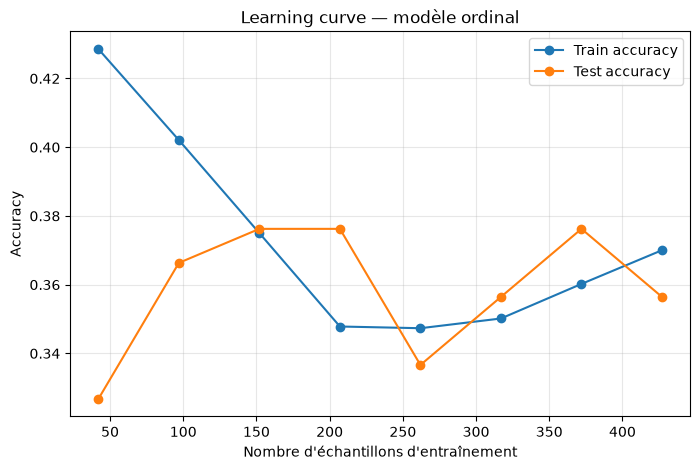

In [90]:
n_samples_list, train_scores, test_scores = plot_learning_curve_ordinal(
    X_train_clean[cols_numeriques], y_train_clean,
    X_test_clean[cols_numeriques], y_test_clean
)
# utiliser que les colonnes num pour la learning curve car brands a + de 200 modalités et ca fait que le mod a bcp trop de modalités pour predire le nutriscore, ca fait qu'il est en surapprentissage

# IL faudrait faire plusieurs categories de brands --> bio, discount, lux
# Il faut faire PCA ou shap

In [91]:
counts = X_train_clean['brands'].value_counts()
print(f"Nombre de marques distinctes : {counts.shape[0]}")
print(f"Nombre de marques avec 1 seul produit : {(counts == 1).sum()}")
print(f"Nombre de marques avec 5+ produits : {(counts >= 5).sum()}")
print(counts.describe())

KeyError: 'brands'

In [ ]:
top_n = 10 #dans notre dataset plusieurs produits différents ont la même marque donc on va prendre le top 20 des marques les + recurrentes . TOutes les marques qui n'apparaissent qu'une fois sont appelé "autre"
top_brands = X_train_clean['brands'].value_counts().nlargest(top_n).index 
# les 20 plus fréquentes

X_train_clean['brands_grouped'] = X_train_clean['brands'].where(
    X_train_clean['brands'].isin(top_brands), 'Autre'
)
X_test_clean['brands_grouped'] = X_test_clean['brands'].where(
    X_test_clean['brands'].isin(top_brands), 'Autre'
)

# On ré-encode avec la version groupée
X_train_final2, X_test_final2, encoder2 = encode_categorical(
    X_train_clean, X_test_clean,
    cols_categorielles=['brands_grouped'],
    cols_numeriques=cols_numeriques
)

# On réentraîne le modèle sur cette version réduite
result2, scaler2 = train_ordinal_logit(X_train_final2, y_train_clean)

# Pour chaque ligne : si la marque est dans le top 20, on la garde telle quelle.
# Sinon, on la remplace par 'Autre'.

Optimization terminated successfully.
         Current function value: 1.379632
         Iterations: 62
         Function evaluations: 63
         Gradient evaluations: 63
                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -586.34
Model:                   OrderedModel   AIC:                             1215.
Method:            Maximum Likelihood   BIC:                             1300.
Date:                Wed, 26 Aug 2026                                         
Time:                        12:16:16                                         
No. Observations:                 425                                         
Df Residuals:                     404                                         
Df Model:                          17                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]


100%|██████████| 94/94 [00:38<00:00,  2.42it/s]


Modalités de brands les plus importantes (SHAP moyen absolu) :
brands_grouped_Autre                                0.055892
brands_grouped_Kazidomi                             0.048896
brands_grouped_Madelaine Chocolate Novelties        0.015367
brands_grouped_More                                 0.007618
brands_grouped_Vintage Bee  Inc.                    0.004145
brands_grouped_Healthy Food Brands Llc              0.001576
brands_grouped_Trader Joe's                         0.001086
brands_grouped_Welch's,  Healthy Food Brands Llc    0.000795
brands_grouped_Bijou                                0.000171
brands_grouped_Ryan Orchards                        0.000000
dtype: float64


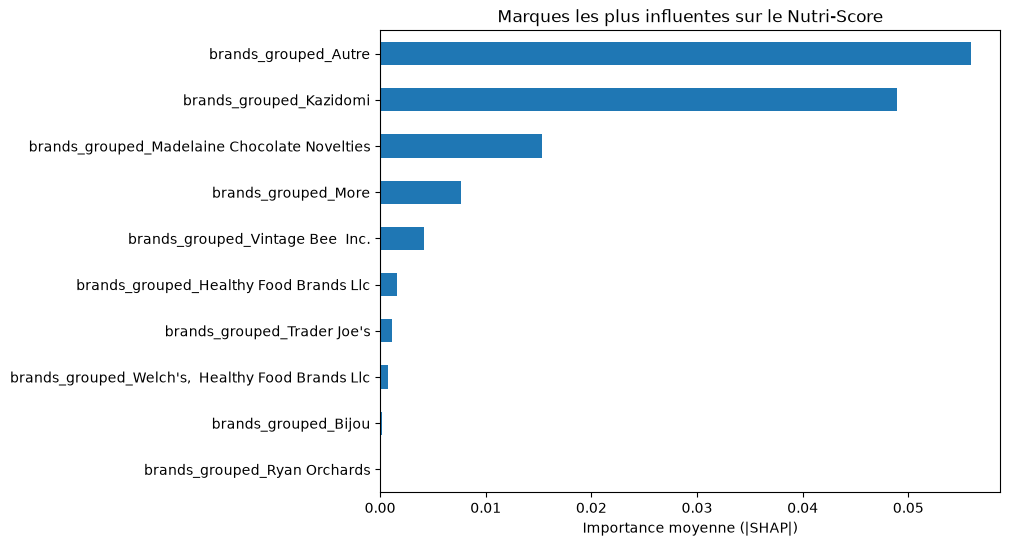

In [ ]:
from version2 import explain_shap_brands
#SHAP) devient gérable avec ~10 colonnes au lieu de 220.
cols_brands_encoded = [c for c in X_train_final2.columns if c.startswith('brands_grouped_')]

shap_values, importance_brands = explain_shap_brands(
    result2, scaler2, X_train_final2, X_test_final2, cols_brands_encoded
)

importance_brands.plot(kind='barh', figsize=(8, 6))
plt.xlabel("Importance moyenne (|SHAP|)")
plt.title("Marques les plus influentes sur le Nutri-Score")
plt.gca().invert_yaxis()
plt.show()

# La marque n'est peut etre pas une bonne variable explicative car peut fausser notre modele, en  faisant de l'overfitting car selon la marque les produits sont visés. 

# Donc on va essayer les pays

In [92]:
counts = X_train_clean['countries'].value_counts()
print(f"Nombre de marques distinctes : {counts.shape[0]}")
print(f"Nombre de marques avec 1 seul produit : {(counts == 1).sum()}")
print(f"Nombre de marques avec 5+ produits : {(counts >= 5).sum()}")
print(counts.describe())

Nombre de marques distinctes : 74
Nombre de marques avec 1 seul produit : 46
Nombre de marques avec 5+ produits : 10
count     74.000000
mean       5.770270
std       21.861048
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max      182.000000
Name: count, dtype: float64


In [93]:
top_n = 10 #dans notre dataset plusieurs produits différents ont la même marque donc on va prendre le top 20 des marques les + recurrentes . TOutes les marques qui n'apparaissent qu'une fois sont appelé "autre"
top_brands = X_train_clean['countries'].value_counts().nlargest(top_n).index 
# les 20 plus fréquentes

X_train_clean['countries_grouped'] = X_train_clean['countries'].where(
    X_train_clean['countries'].isin(top_brands), 'Autre'
)
X_test_clean['countries_grouped'] = X_test_clean['countries'].where(
    X_test_clean['countries'].isin(top_brands), 'Autre'
)

# On ré-encode avec la version groupée
X_train_final2, X_test_final2, encoder2 = encode_categorical(
    X_train_clean, X_test_clean,
    cols_categorielles=['countries_grouped'],
    cols_numeriques=cols_numeriques
)

# On réentraîne le modèle sur cette version réduite
result2, scaler2 = train_ordinal_logit(X_train_final2, y_train_clean)


Optimization terminated successfully.
         Current function value: 1.376450
         Iterations: 36
         Function evaluations: 37
         Gradient evaluations: 37
                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -587.74
Model:                   OrderedModel   AIC:                             1217.
Method:            Maximum Likelihood   BIC:                             1303.
Date:                Wed, 26 Aug 2026                                         
Time:                        15:56:53                                         
No. Observations:                 427                                         
Df Residuals:                     406                                         
Df Model:                          17                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------

100%|██████████| 101/101 [00:55<00:00,  1.83it/s]


Modalités de brands les plus importantes (SHAP moyen absolu) :
countries_grouped_United States        0.034158
countries_grouped_India                0.011609
countries_grouped_en:fr                0.008495
countries_grouped_France               0.004080
countries_grouped_en:United States     0.002793
countries_grouped_Belgium              0.002525
countries_grouped_en:us                0.000392
countries_grouped_en:United Kingdom    0.000331
countries_grouped_United Kingdom       0.000042
countries_grouped_en:Ireland           0.000000
dtype: float64


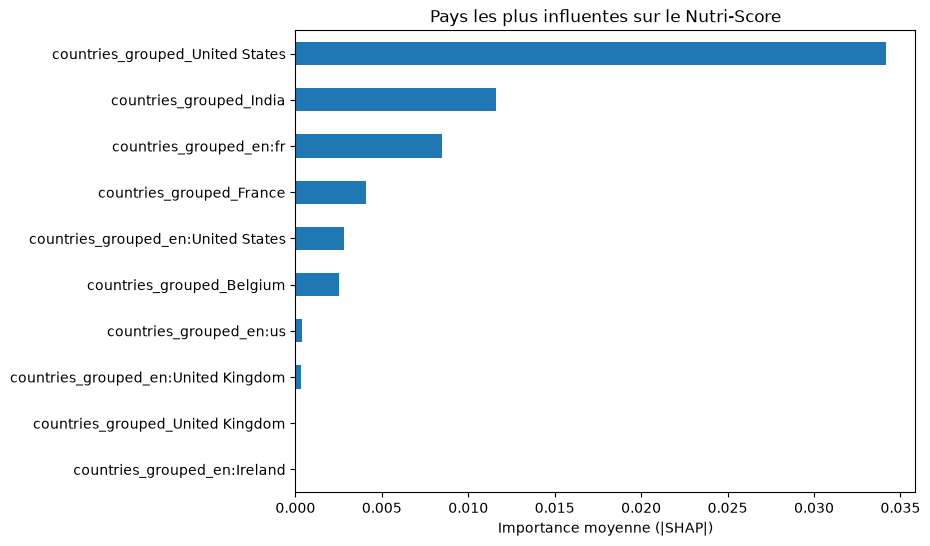

In [94]:
from version2 import explain_shap_brands
#SHAP) devient gérable avec ~10 colonnes au lieu de 220.
cols_countries_encoded = [c for c in X_train_final2.columns if c.startswith('countries_grouped_')]

shap_values, importance_countries = explain_shap_brands(
    result2, scaler2, X_train_final2, X_test_final2, cols_countries_encoded
)

importance_countries.plot(kind='barh', figsize=(8, 6))
plt.xlabel("Importance moyenne (|SHAP|)")
plt.title("Pays les plus influentes sur le Nutri-Score")
plt.gca().invert_yaxis()
plt.show()

# on compare notre modele à un nouveau avce countries 

In [95]:

print([c for c in X_train_final.columns if 'United States' in c])

['countries_Canada,United States', 'countries_United States', 'countries_United States, World', 'countries_en:Canada,en:United States', 'countries_en:United States', 'countries_en:canada,en:United States']


In [96]:
from version2 import (
    train_ordinal_logit,
    evaluate_ordinal_model,
    run_lasso_logit,
)


cols_selection = cols_numeriques + ['countries_Canada,United States', 'countries_United States', 'countries_United States, World', 'countries_en:Canada,en:United States', 'countries_en:United States', 'countries_en:canada,en:United States']

X_train_subset = X_train_final[cols_selection].copy()
X_test_subset = X_test_final[cols_selection].copy()

# Entraînement sur ce sous-ensemble de variables
result, scaler = train_ordinal_logit(X_train_subset, y_train_clean)
pred, probas = evaluate_ordinal_model(result, scaler, X_test_subset, y_test_clean)

model, lasso_scaler = run_lasso_logit(X_train_subset, y_train_clean)

Optimization terminated successfully.
         Current function value: 1.414764
         Iterations: 52
         Function evaluations: 53
         Gradient evaluations: 53
                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -604.10
Model:                   OrderedModel   AIC:                             1242.
Method:            Maximum Likelihood   BIC:                             1311.
Date:                Wed, 26 Aug 2026                                         
Time:                        15:57:51                                         
No. Observations:                 427                                         
Df Residuals:                     410                                         
Df Model:                          13                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
------------

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring'

Lignes utilisées : 427
Accuracy (train) : 0.412

Coefficients par classe (Lasso logistique) :

  Classe 'a' :
    energy_100g: 0.0000
    saturated-fat_100g: -0.0282
    sugars_100g: 0.0000
    salt_100g: -0.1637
    proteins_100g: 0.4272
    energy-kcal_100g: 0.0503
    carbohydrates_100g: 0.0000
    countries_Canada,United States: 0.1940
    countries_United States: -0.2326
    countries_United States, World: 0.0000
    countries_en:Canada,en:United States: 0.1874
    countries_en:United States: 0.1523
    countries_en:canada,en:United States: 0.1725

  Classe 'b' :
    energy_100g: -0.0172
    saturated-fat_100g: -0.0799
    sugars_100g: -0.2363
    salt_100g: -0.3751
    proteins_100g: 0.0000
    energy-kcal_100g: -0.0614
    carbohydrates_100g: 0.0000
    countries_Canada,United States: 0.0000
    countries_United States: 0.0374
    countries_United States, World: 0.0000
    countries_en:Canada,en:United States: 0.0000
    countries_en:United States: 0.0000
    countries_en:canada

In [97]:
ORDRE_NUTRISCORE = ["a", "b", "c", "d", "e"]
from sklearn.metrics import accuracy_score

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_subset),
    columns=X_train_subset.columns,
    index=X_train_subset.index
)
probas_train = result.predict(X_train_scaled)
probas_train.columns = ORDRE_NUTRISCORE
pred_train = probas_train.idxmax(axis=1)
acc_train = accuracy_score(y_train_clean, pred_train)

# Accuracy sur test (déjà calculée dans evaluate_ordinal_model, on la refait ici pour l'avoir en variable)
acc_test = accuracy_score(y_test_clean, pred)  # `pred` vient de evaluate_ordinal_model

print(f"Accuracy train : {acc_train:.3f}")
print(f"Accuracy test : {acc_test:.3f}")

Accuracy train : 0.370
Accuracy test : 0.337


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def plot_learning_curve_ordinal(X_train, y_train, X_test, y_test, ordre=ORDRE_NUTRISCORE, n_points=8, random_state=42):
    """
    Trace la learning curve d'un modèle ordinal en faisant varier
    la taille du jeu d'entraînement.
    """
    tailles = np.linspace(0.1, 1.0, n_points)
    train_scores = []
    test_scores = []
    n_samples_list = []

    rng = np.random.RandomState(random_state)

    for frac in tailles:
        n = int(frac * len(X_train))
        idx = rng.choice(X_train.index, size=n, replace=False)
        X_sub = X_train.loc[idx]
        y_sub = y_train.loc[idx]

        # entraînement sur le sous-échantillon
        result, scaler = train_ordinal_logit(X_sub, y_sub, ordre=ordre)

        # accuracy sur le sous-échantillon d'entraînement lui-même
        X_sub_scaled = pd.DataFrame(scaler.transform(X_sub), columns=X_sub.columns, index=X_sub.index)
        probas_train = result.predict(X_sub_scaled)
        probas_train.columns = ordre
        pred_train = probas_train.idxmax(axis=1)
        train_scores.append(accuracy_score(y_sub, pred_train))

        # accuracy sur le jeu de test (fixe, toujours le même)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
        probas_test = result.predict(X_test_scaled)
        probas_test.columns = ordre
        pred_test = probas_test.idxmax(axis=1)
        test_scores.append(accuracy_score(y_test, pred_test))

        n_samples_list.append(n)

    plt.figure(figsize=(8, 5))
    plt.plot(n_samples_list, train_scores, marker='o', label='Train accuracy')
    plt.plot(n_samples_list, test_scores, marker='o', label='Test accuracy')
    plt.xlabel("Nombre d'échantillons d'entraînement")
    plt.ylabel("Accuracy")
    plt.title("Learning curve — modèle ordinal")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return n_samples_list, train_scores, test_scores



Optimization terminated successfully.
         Current function value: 1.333198
         Iterations: 49
         Function evaluations: 50
         Gradient evaluations: 50


c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -55.994
Model:                   OrderedModel   AIC:                             146.0
Method:            Maximum Likelihood   BIC:                             175.5
Date:                Wed, 26 Aug 2026                                         
Time:                        15:58:06                                         
No. Observations:                  42                                         
Df Residuals:                      25                                         
Df Model:                          13                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
energy_100g                             -5.5661        nan        nan        na

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -135.11
Model:                   OrderedModel   AIC:                             304.2
Method:            Maximum Likelihood   BIC:                             348.0
Date:                Wed, 26 Aug 2026                                         
Time:                        15:58:08                                         
No. Observations:                  97                                         
Df Residuals:                      80                                         
Df Model:                          13                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
energy_100g                              0.2140        nan        nan        na

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -295.48
Model:                   OrderedModel   AIC:                             625.0
Method:            Maximum Likelihood   BIC:                             681.6
Date:                Wed, 26 Aug 2026                                         
Time:                        15:58:13                                         
No. Observations:                 207                                         
Df Residuals:                     190                                         
Df Model:                          13                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
energy_100g                              0.0448        nan        nan        na

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:                -525.88
Model:                   OrderedModel   AIC:                             1086.
Method:            Maximum Likelihood   BIC:                             1152.
Date:                Wed, 26 Aug 2026                                         
Time:                        15:58:19                                         
No. Observations:                 372                                         
Df Residuals:                     355                                         
Df Model:                          13                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
energy_100g                              0.1541        nan        nan        na

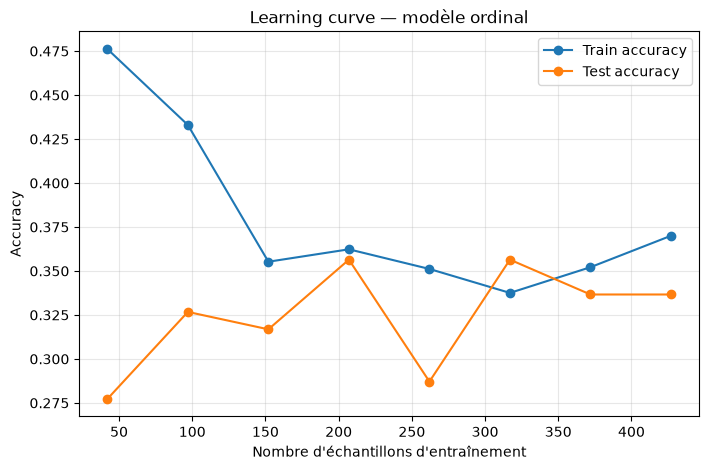

In [99]:
n_samples_list, train_scores, test_scores = plot_learning_curve_ordinal(
    X_train_subset, y_train_clean,
    X_test_subset, y_test_clean
)